In [ ]:
cchina import sys, os
REPO_DIR = os.path.dirname(os.path.abspath("__file__"))
sys.path.insert(0, os.path.join(REPO_DIR, "src"))

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [3]:
import pandas as pd
from sklearn.model_selection import KFold
from crt_cgan import ConditionalGAN, crt_calibration_efficient, crt_calibration_precomputed
import numpy as np
from tqdm.notebook import tqdm
import time

In [4]:
from methods import (condor_score, nkci_score, nhsic_score, kcondor_score, cmi_score, 
                     hsic_hyppo_score, partial_dcorr_score, pdnhsic_v2, 
                     Kcondor_v2, Kcondor_v2_opt, Kcondor_v2_opt2, Kcondor_v2_precomputed_factory,
                     Kcondor_v3, kci_pval, nhsic, partial_corr_pg_score)

In [5]:
from synthetic import generate_ranking_data, generate_ranking, generate_ranking_data_reverse

In [6]:
# Fixed parameters
kx = 5
kt = 5
random_state = 22
K = 5
B = 200

# Fixed gamma and beta values
gamma = 0.5
beta = 0.5

# Values to vary for runtime testing
#n_values = [100, 500, 1000, 5000]
#n_values = [100, 1000, 2000, 5000]
n_values = [5000]
#n_values = [1000,10000,20000,50000]
#n_values = [10, 100, 200, 500]
#d_combinations = [(1,1), (2,2), (5,5), (10,10)]
#d_combinations = [(1,1),(5,5),(10,10)]
d_combinations = [(5,5)]

In [7]:
methods = {
    #"Condor": ("standard", Kcondor_v2),
    #"Condor_opt": ("standard", Kcondor_v2_opt),  # Phase 1: einsum + pre-computed divisions
    #"Condor_opt2": ("standard", Kcondor_v2_opt2),  # Phase 2: symmetry exploitation + fused ops
    ###"Condor_precomp": ("precomputed", Kcondor_v2_precomputed_factory),  # Phase 3: pre-compute R_X and residualized r
    ###"nKCI": ("standard", nkci_score),
    #'nhsic': ("standard", nhsic),
    #'cmi_score': ("standard", cmi_score), 
    'partial_dcorr_score': ("standard", partial_dcorr_score),
    ###'pearson_residual_corr': ("standard", partial_corr_pg_score)
}

In [8]:
#methods ={'pearson_residual_corr': partial_corr_pg_score}

TESTING PRECOMPUTED OPTIMIZATION (Phase 3)

This test compares:
  1. Original Kcondor_v2 (baseline)
  2. Kcondor_v2_opt2 (Phase 1+2 optimizations)
  3. Kcondor_v2_precomputed (Phase 3: pre-compute R_X)

Test configuration: n=200, d=(1,1), B=50 (reduced for quick test)
----------------------------------------------------------------------

Training cGAN generators for test...


✓ Generators trained

TEST 1: Original Kcondor_v2
Time: 1.06s
P-value: 0.000000

TEST 2: Kcondor_v2_opt2 (Phase 1+2)
Time: 0.71s
P-value: 0.000000
Speedup: 1.50x faster than original
P-value difference: 0.00e+00

TEST 3: Kcondor_v2_precomputed (Phase 3: Pre-compute R_X)
Time: 0.37s
P-value: 0.000000
Speedup: 2.90x faster than original
Additional speedup over opt2: 1.94x
P-value difference from original: 0.00e+00

SUMMARY
               Method  Time (s)  Speedup  P-value  P-val Error
             Original  1.063994 1.000000      0.0          0.0
     Opt2 (Phase 1+2)  0.709432 1.499783      0.0          0.0
Precomputed (Phase 3)  0.366610 2.902252      0.0          0.0

✓ Dedicated test results saved to: dedicated_test_results_n200_d1_1_B50.csv


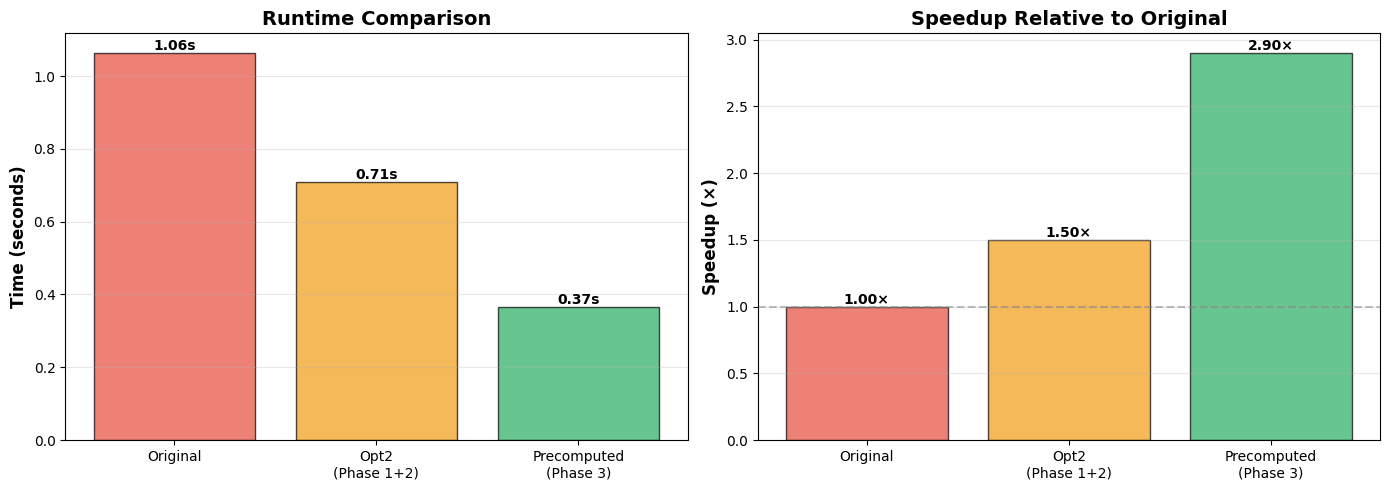


✓ Test completed successfully!
✓ P-values are consistent (max error: 0.00e+00)
✓ Precomputed version is 2.90× faster than original
✓ Precomputed version is 1.94× faster than opt2


In [9]:
######### DEDICATED TEST: Precomputed Optimization #########
print("="*70)
print("TESTING PRECOMPUTED OPTIMIZATION (Phase 3)")
print("="*70)
print("\nThis test compares:")
print("  1. Original Kcondor_v2 (baseline)")
print("  2. Kcondor_v2_opt2 (Phase 1+2 optimizations)")
print("  3. Kcondor_v2_precomputed (Phase 3: pre-compute R_X)")
print("\nTest configuration: n=200, d=(1,1), B=50 (reduced for quick test)")
print("-"*70)

# Test parameters
test_n = 200
test_d_o, test_d_p = 1, 1
test_B = 50  # Reduced for quick test
test_K = 3   # Reduced folds for quick test

# Generate test data
np.random.seed(random_state)
X_test, Z_test, _ = generate_ranking_data(n=test_n, d_o=test_d_o, d_p=test_d_p, 
                                          kx=kx, kt=kt, gamma=gamma, random_state=random_state)
R_test = generate_ranking(X_test, Z_test, beta=beta, random_state=random_state)

# Create test splits and train generators
kf_test = KFold(n_splits=test_K, shuffle=True, random_state=random_state)
kf_test_splits = list(kf_test.split(X_test))

print("\nTraining cGAN generators for test...")
test_generators = []
for train_idx, _ in kf_test_splits:
    gen = ConditionalGAN(x_dim=X_test.shape[1], z_dim=Z_test.shape[1], epochs=20)
    gen.fit(X_test[train_idx], Z_test[train_idx])
    test_generators.append(gen)
print("✓ Generators trained")

# Test 1: Original Kcondor_v2
print("\n" + "="*70)
print("TEST 1: Original Kcondor_v2")
print("="*70)
start = time.time()
p_val_original = crt_calibration_efficient(X_test, Z_test, R_test, 
                                           scoring_function=Kcondor_v2,
                                           kf_splits=kf_test_splits, 
                                           trained_generators=test_generators, B=test_B)
time_original = time.time() - start
print(f"Time: {time_original:.2f}s")
print(f"P-value: {p_val_original:.6f}")

# Test 2: Optimized Kcondor_v2_opt2
print("\n" + "="*70)
print("TEST 2: Kcondor_v2_opt2 (Phase 1+2)")
print("="*70)
start = time.time()
p_val_opt2 = crt_calibration_efficient(X_test, Z_test, R_test, 
                                       scoring_function=Kcondor_v2_opt2,
                                       kf_splits=kf_test_splits, 
                                       trained_generators=test_generators, B=test_B)
time_opt2 = time.time() - start
speedup_opt2 = time_original / time_opt2
print(f"Time: {time_opt2:.2f}s")
print(f"P-value: {p_val_opt2:.6f}")
print(f"Speedup: {speedup_opt2:.2f}x faster than original")
print(f"P-value difference: {abs(p_val_opt2 - p_val_original):.2e}")

# Test 3: Precomputed Kcondor
print("\n" + "="*70)
print("TEST 3: Kcondor_v2_precomputed (Phase 3: Pre-compute R_X)")
print("="*70)
start = time.time()
p_val_precomp = crt_calibration_precomputed(X_test, Z_test, R_test, 
                                            scoring_factory=Kcondor_v2_precomputed_factory,
                                            kf_splits=kf_test_splits, 
                                            trained_generators=test_generators, B=test_B)
time_precomp = time.time() - start
speedup_precomp = time_original / time_precomp
additional_speedup = time_opt2 / time_precomp
print(f"Time: {time_precomp:.2f}s")
print(f"P-value: {p_val_precomp:.6f}")
print(f"Speedup: {speedup_precomp:.2f}x faster than original")
print(f"Additional speedup over opt2: {additional_speedup:.2f}x")
print(f"P-value difference from original: {abs(p_val_precomp - p_val_original):.2e}")

# Summary
print("\n" + "="*70)
print("SUMMARY")
print("="*70)
results_df = pd.DataFrame({
    'Method': ['Original', 'Opt2 (Phase 1+2)', 'Precomputed (Phase 3)'],
    'Time (s)': [time_original, time_opt2, time_precomp],
    'Speedup': [1.0, speedup_opt2, speedup_precomp],
    'P-value': [p_val_original, p_val_opt2, p_val_precomp],
    'P-val Error': [0.0, abs(p_val_opt2 - p_val_original), abs(p_val_precomp - p_val_original)]
})
print(results_df.to_string(index=False))

# Save dedicated test results to CSV
dedicated_test_filename = f"dedicated_test_results_n{test_n}_d{test_d_o}_{test_d_p}_B{test_B}.csv"
results_df.to_csv(dedicated_test_filename, index=False)
print(f"\n✓ Dedicated test results saved to: {dedicated_test_filename}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Runtime comparison
methods_plot = ['Original', 'Opt2\n(Phase 1+2)', 'Precomputed\n(Phase 3)']
times_plot = [time_original, time_opt2, time_precomp]
colors_plot = ['#e74c3c', '#f39c12', '#27ae60']
bars = ax1.bar(methods_plot, times_plot, color=colors_plot, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Runtime Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar, time_val in zip(bars, times_plot):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{time_val:.2f}s',
             ha='center', va='bottom', fontweight='bold')

# Plot 2: Speedup
speedups = [1.0, speedup_opt2, speedup_precomp]
bars2 = ax2.bar(methods_plot, speedups, color=colors_plot, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Speedup (×)', fontsize=12, fontweight='bold')
ax2.set_title('Speedup Relative to Original', fontsize=14, fontweight='bold')
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax2.grid(axis='y', alpha=0.3)
# Add value labels
for bar, speedup_val in zip(bars2, speedups):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{speedup_val:.2f}×',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✓ Test completed successfully!")
print(f"✓ P-values are consistent (max error: {max(abs(p_val_opt2 - p_val_original), abs(p_val_precomp - p_val_original)):.2e})")
print(f"✓ Precomputed version is {speedup_precomp:.2f}× faster than original")
print(f"✓ Precomputed version is {additional_speedup:.2f}× faster than opt2")
print("="*70)

In [10]:
# Initialize results storage: {method_name: {d_combination: {n: runtime}}}
runtime_results = {name: {str(d): {} for d in d_combinations} for name in methods}

In [11]:
# Runtime measurement loop
for d_o, d_p in d_combinations:
    print(f"\n{'='*60}\nTesting d_o={d_o}, d_p={d_p}\n{'='*60}")
    
    for n in n_values:
        print(f"\n--- Testing n={n} ---")
        
        # Generate data with fixed gamma and beta
        X, Z, _ = generate_ranking_data(n=n, d_o=d_o, d_p=d_p, kx=kx, kt=kt, gamma=gamma, random_state=random_state)
        
        kf = KFold(n_splits=K, shuffle=True, random_state=random_state)
        kf_splits = list(kf.split(X))
        
        # Train cGAN generators
        trained_generators = []
        for train_idx, _ in kf_splits:
            generator = ConditionalGAN(x_dim=X.shape[1], z_dim=Z.shape[1])
            generator.fit(X[train_idx], Z[train_idx])
            trained_generators.append(generator)
        
        # Generate ranking with fixed beta
        R = generate_ranking(X, Z, beta=beta, random_state=random_state)
        
        # Measure runtime for each method
        for name, (method_type, func) in methods.items():
            start_time = time.time()
            
            if method_type == "precomputed":
                # Use the optimized precomputed calibration
                p_val = crt_calibration_precomputed(X, Z, R, scoring_factory=func, 
                                                    kf_splits=kf_splits, trained_generators=trained_generators, B=B)
            elif name in ["Condor", "Condor_opt", "Condor_opt2", "pearson_residual_corr", "cmi_score"]:
                # Use standard calibration
                p_val = crt_calibration_efficient(X, Z, R, scoring_function=func, 
                                                  kf_splits=kf_splits, trained_generators=trained_generators, B=B)
            elif name == "partial_dcorr_score":
                p_val = partial_dcorr_score(R, Z, X)
            elif name == "nKCI":
                p_val = kci_pval(R, Z, X)
            elif name == "nhsic":
                p_val = nhsic(R, Z, X)
            
            elapsed_time = time.time() - start_time
            
            # Store runtime
            runtime_results[name][str((d_o, d_p))][n] = elapsed_time
            
            print(f"Method: {name}, n: {n}, d: ({d_o},{d_p}), Time: {elapsed_time:.2f}s, p-value: {p_val:.4f}")

print("\nRuntime measurement completed!")


Testing d_o=5, d_p=5

--- Testing n=5000 ---


KeyboardInterrupt: 

In [ ]:
# save runtime_results

with open("runtime_results_partial_dcorr_score.pkl", "wb") as f:
    pickle.dump(runtime_results, f)
print("✓ Runtime results saved to 'runtime_results_partial_dcorr_score.pkl'")

In [ ]:
import pickle

In [ ]:
# Load pre-computed runtime results (stored in OLD/)
OLD_DIR = os.path.join(REPO_DIR, "OLD")
with open(os.path.join(OLD_DIR, "runtime_results_cmi.pkl"), "rb") as f:
    runtime_result = pickle.load(f)

In [ ]:
with open(os.path.join(OLD_DIR, "runtime_results_1000_20000.pkl"), "rb") as f:
    runtime_results_l = pickle.load(f)

In [ ]:
with open(os.path.join(OLD_DIR, "runtime_results_50000.pkl"), "rb") as f:
    runtime_results_p = pickle.load(f)

In [ ]:
# runtime_results_l merge with runtime_results
for method in runtime_results_p:
    for d_key in runtime_results_p[method]:
        for n_key in runtime_results_l[method][d_key]:
            runtime_results_p[method][d_key][n_key] = runtime_results_l[method][d_key][n_key] 

In [ ]:
# add runtime_result in runtime_results_p
runtime_results_p['cmi_score'] = runtime_result['cmi_score']

In [2]:
runtime_results_p = {'Condor_precomp': {'(5, 5)': {50000: 24454.053590774536,
   1000: 5.686921834945679,
   10000: 421.03850650787354,
   20000: 3053.770085334778}},
 'nKCI': {'(5, 5)': {50000: 32715.098182439804,
   1000: 0.9339931011199951,
   10000: 339.68362164497375,
   20000: 2702.1139752864838}},
 'pearson_residual_corr': {'(5, 5)': {1000: 121.82,
   10000: 6489.2345}},
 'cmi_score': {'(5, 5)': {1000: 3.47236967086792,
   10000: 45.79529309272766,
   20000: 127.31802272796631,
   50000: 508.1113440990448}}}

In [3]:
# change names in runtime_results_p:
# Condor_precomp --> Condor, nKCI --> KCI, pearson_residual_corr  --> pdCor, cmi_score --> CMI
runtime_results_p_renamed = {}
for method, results in runtime_results_p.items():
    if method == "Condor_precomp":
        new_method = "Condor"
    elif method == "nKCI":
        new_method = "KCI"
    elif method == "pearson_residual_corr":
        new_method = "pdCor"
    elif method == "cmi_score":
        new_method = "CMI"
    else:
        new_method = method
    runtime_results_p_renamed[new_method] = results
    
runtime_results_p = runtime_results_p_renamed

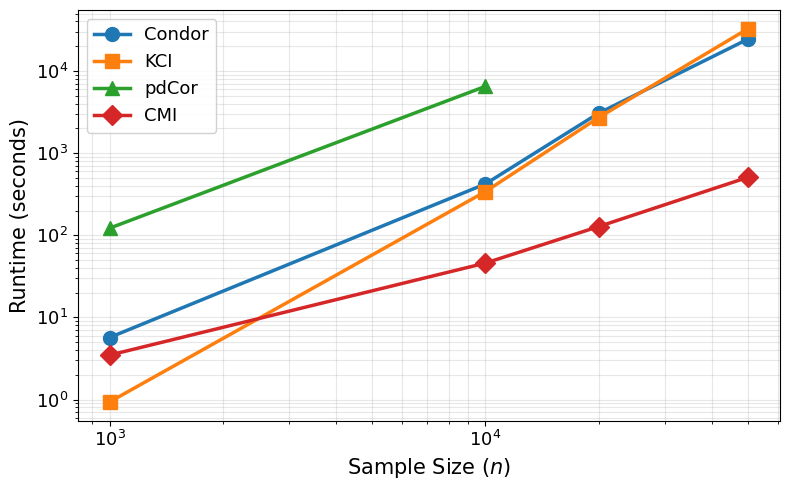

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Extract all methods, d_combinations, and n_values from runtime_results_p
all_methods = list(runtime_results_p.keys())
all_d_keys = sorted(set(d for m in runtime_results_p.values() for d in m.keys()))

# Marker and line styles for distinction
markers = ['o', 's', '^', 'D', 'v', 'P']
cmap = plt.cm.tab10
method_colors = {m: cmap(i) for i, m in enumerate(all_methods)}
method_markers = {m: markers[i % len(markers)] for i, m in enumerate(all_methods)}

fig, axes = plt.subplots(1, len(all_d_keys), figsize=(8 * len(all_d_keys), 5), squeeze=False)

for col, d_key in enumerate(all_d_keys):
    ax = axes[0, col]
    for method in all_methods:
        if d_key in runtime_results_p[method]:
            n_times = runtime_results_p[method][d_key]
            ns = sorted(n_times.keys())
            times = [n_times[n] for n in ns]
            ax.plot(ns, times, marker=method_markers[method], label=method,
                    linewidth=2.5, markersize=10, color=method_colors[method])

    ax.set_xlabel('Sample Size ($n$)', fontsize=15)
    ax.set_ylabel('Runtime (seconds)', fontsize=15)
    #ax.set_title(f'$d = {d_key}$', fontsize=26)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.tick_params(axis='both', which='minor', labelsize=13)
    ax.legend(fontsize=13, framealpha=0.9)
    ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# save pdf
fig.savefig("runtime_results_p.pdf", bbox_inches='tight')

In [ ]:
# Save runtime results
import pickle
with open(f"runtime_results_gamma_{gamma}_beta_{beta}_kx_{kx}_kt_{kt}_K_{K}_B_{B}.pkl", 'wb') as f:
    pickle.dump(runtime_results, f)
print(f"Runtime results saved to: runtime_results_gamma_{gamma}_beta_{beta}_kx_{kx}_kt_{kt}_K_{K}_B_{B}.pkl")

In [ ]:
# LOAD "runtime_results_gamma_{gamma}_beta_{beta}_kx_{kx}_kt_{kt}_K_{K}_B_{B}.pkl"


In [ ]:
######### OPTIMIZATION ANALYSIS #########
print("="*80)
print("OPTIMIZATION ANALYSIS: Precomputed vs Original")
print("="*80)

# Extract Condor methods only
condor_methods = {k: v for k, v in runtime_results.items() if 'Condor' in k}

if 'Condor' in runtime_results and 'Condor_precomp' in runtime_results:
    print("\nSpeedup Analysis (Precomputed vs Original):")
    print("-"*80)
    
    speedup_data = []
    
    for d_str in runtime_results['Condor'].keys():
        for n in runtime_results['Condor'][d_str].keys():
            time_orig = runtime_results['Condor'][d_str][n]
            time_precomp = runtime_results['Condor_precomp'][d_str][n]
            speedup = time_orig / time_precomp
            
            speedup_data.append({
                'd': d_str,
                'n': n,
                'Original (s)': time_orig,
                'Precomputed (s)': time_precomp,
                'Speedup (×)': speedup,
                'Time Saved (s)': time_orig - time_precomp,
                'Reduction (%)': (1 - time_precomp/time_orig) * 100
            })
    
    speedup_df = pd.DataFrame(speedup_data)
    print(speedup_df.to_string(index=False))
    
    # Save speedup analysis results to CSV
    speedup_filename = f"speedup_analysis_gamma_{gamma}_beta_{beta}_kx_{kx}_kt_{kt}_K_{K}_B_{B}.csv"
    speedup_df.to_csv(speedup_filename, index=False)
    print(f"\n✓ Speedup analysis results saved to: {speedup_filename}")
    
    # Overall statistics
    print("\n" + "="*80)
    print("OVERALL STATISTICS")
    print("="*80)
    print(f"Average speedup: {speedup_df['Speedup (×)'].mean():.2f}×")
    print(f"Max speedup: {speedup_df['Speedup (×)'].max():.2f}× (n={speedup_df.loc[speedup_df['Speedup (×)'].idxmax(), 'n']}, d={speedup_df.loc[speedup_df['Speedup (×)'].idxmax(), 'd']})")
    print(f"Min speedup: {speedup_df['Speedup (×)'].min():.2f}× (n={speedup_df.loc[speedup_df['Speedup (×)'].idxmin(), 'n']}, d={speedup_df.loc[speedup_df['Speedup (×)'].idxmin(), 'd']})")
    print(f"Average time reduction: {speedup_df['Reduction (%)'].mean():.1f}%")
    print(f"Total time saved: {speedup_df['Time Saved (s)'].sum():.1f}s")
    
    # Plot speedup vs n for each d
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Speedup vs n
    ax1 = axes[0]
    d_combinations_str = list(set(speedup_df['d']))
    for d_str in sorted(d_combinations_str):
        data_d = speedup_df[speedup_df['d'] == d_str].sort_values('n')
        ax1.plot(data_d['n'], data_d['Speedup (×)'], marker='o', 
                label=f'd={d_str}', linewidth=2, markersize=10)
    
    ax1.set_xlabel('Sample Size (n)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Speedup (×)', fontsize=14, fontweight='bold')
    ax1.set_title('Precomputed Speedup vs Sample Size', fontsize=16, fontweight='bold')
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_xscale('log')
    
    # Plot 2: Time comparison
    ax2 = axes[1]
    
    # Get average across d for each n
    avg_by_n = speedup_df.groupby('n').agg({
        'Original (s)': 'mean',
        'Precomputed (s)': 'mean'
    }).reset_index()
    
    x = np.arange(len(avg_by_n))
    width = 0.35
    
    bars1 = ax2.bar(x - width/2, avg_by_n['Original (s)'], width, 
                    label='Original', color='#e74c3c', alpha=0.7, edgecolor='black')
    bars2 = ax2.bar(x + width/2, avg_by_n['Precomputed (s)'], width, 
                    label='Precomputed', color='#27ae60', alpha=0.7, edgecolor='black')
    
    ax2.set_xlabel('Sample Size (n)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Time (seconds)', fontsize=14, fontweight='bold')
    ax2.set_title('Runtime Comparison (Average across d)', fontsize=16, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(avg_by_n['n'])
    ax2.legend(fontsize=12)
    ax2.grid(axis='y', alpha=0.3)
    
    # Add speedup annotations
    for i, (idx, row) in enumerate(avg_by_n.iterrows()):
        speedup_val = row['Original (s)'] / row['Precomputed (s)']
        ax2.text(i, max(row['Original (s)'], row['Precomputed (s)']) * 1.05,
                f'{speedup_val:.1f}×',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Comparison across all optimization phases
    if 'Condor_opt' in runtime_results and 'Condor_opt2' in runtime_results:
        print("\n" + "="*80)
        print("PROGRESSIVE OPTIMIZATION COMPARISON")
        print("="*80)
        
        # Compare all versions for a specific case
        sample_d = list(runtime_results['Condor'].keys())[0]
        sample_n = sorted(list(runtime_results['Condor'][sample_d].keys()))[-1]  # Largest n
        
        print(f"\nExample case: n={sample_n}, d={sample_d}")
        print("-"*80)
        
        comparison_data = []
        baseline_time = runtime_results['Condor'][sample_d][sample_n]
        
        for method_name in ['Condor', 'Condor_opt', 'Condor_opt2', 'Condor_precomp']:
            if method_name in runtime_results:
                time_val = runtime_results[method_name][sample_d][sample_n]
                speedup = baseline_time / time_val
                comparison_data.append({
                    'Method': method_name,
                    'Time (s)': time_val,
                    'Speedup vs Original': speedup,
                    'Cumulative Reduction (%)': (1 - time_val/baseline_time) * 100
                })
        
        comp_df = pd.DataFrame(comparison_data)
        print(comp_df.to_string(index=False))
        
        print("\n✓ Phase 3 (Precomputed) provides the biggest speedup by avoiding repeated O(n³) operations!")
        print("✓ Expected behavior: speedup increases with B (number of bootstrap samples)")
        
else:
    print("\nSkipping analysis - not all methods were run in the benchmark.")